### **Data Analysis with Pandas**

##### **Setting up our environment**
- In this section, it is required to prepare the necessary libraries to load, analyze, and visualize the dataset.
- This also ensures the required packages are available and ready before continuing with the analysis.

In [66]:
# Import required library
import pandas as pd
import polars as pl
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
import time

# Check whether the packages for pandas, polars and numpy have been properly imported into the enviroment
print(pd.__version__)
print(pl.__version__)
print(np.__version__)

3.0.5
1.44.1
2.5.3


In [67]:
# Time Counter for Pandas Performance
pandas_read_start = time.perf_counter()

In [68]:
# Import Dataset
sleep_data = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
pandas_read_end = time.perf_counter() # Stop the timer for reading CSV file
pandas_analysis_start = time.perf_counter() # Start the time for data manipulation

##### **Basic Data Inspection**
- In this section, we want to have a quick understanding of the dataset before doing any further analysis. 
- This helps us have a better picture of the dataset’s structure, data types and overall summary statistics

In [69]:
# Check on the first 3 rows and last 3 rows of to have the first glimpse of the dataset
print(sleep_data.head(3))
print(sleep_data.tail(3))

   Person ID Gender  Age         Occupation  Sleep Duration  Quality of Sleep  \
0          1   Male   27  Software Engineer             6.1                 6   
1          2   Male   28             Doctor             6.2                 6   
2          3   Male   28             Doctor             6.2                 6   

   Physical Activity Level  Stress Level BMI Category Blood Pressure  \
0                       42             6   Overweight         126/83   
1                       60             8       Normal         125/80   
2                       60             8       Normal         125/80   

   Heart Rate  Daily Steps Sleep Disorder  
0          77         4200            NaN  
1          75        10000            NaN  
2          75        10000            NaN  
     Person ID  Gender  Age Occupation  Sleep Duration  Quality of Sleep  \
371        372  Female   59      Nurse             8.1                 9   
372        373  Female   59      Nurse             8.1    

In [70]:
# Check the number of dataset rows and columns
print(sleep_data.shape)

# View the column names
print(sleep_data.columns)

(374, 13)
Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='str')


In [71]:
# View dataset's structure, column names, non-missing values, and data types
print(sleep_data.info())

# View summary statistics of the dataset such as count, mean, standard deviation, min, and max
print(sleep_data.describe())

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB
None
        Person ID         Age  S

##### **Check for duplicates**
- For duplicated value, most columns should have duplicated value such as `'gender'`, `'age'` or `'Sleep Disorder'`. 
- However, `'Person ID'` should be a unique identifier for this dataset, so we only check for duplication in this column.

In [72]:
# Check for duplicated value under 'Person ID'
print(f'Number of duplicates: {sleep_data["Person ID"].duplicated().sum()}')

Number of duplicates: 0


##### **Check for missing values**
- From the results of `.info()`, we can see that there are missing values under the column `'Sleep Disorder'` since there are only 155 non-null our of 374 values.
- `.value_counts()` can be used to help understand the count under each category under `'Sleep Disorder'` then filter the dataset to those with null value in this column.

In [73]:
# View count of each category under "Sleep Disorder"
print(sleep_data["Sleep Disorder"].value_counts(dropna=False))

# Filter to rows with missing data under "Sleep Disorder"
sleep_data[sleep_data["Sleep Disorder"].isnull()]

Sleep Disorder
NaN            219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,342,Female,56,Doctor,8.2,9,90,3,Normal Weight,118/75,65,10000,NaN
342,343,Female,56,Doctor,8.2,9,90,3,Normal Weight,118/75,65,10000,NaN
343,344,Female,57,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,NaN
358,359,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,NaN


##### **Basic Filtering and Grouping - Gender vs Sleep Duration**
- In this section, we would like to see if our small sample has a different in sleep duration between male and female and whether the results align with the existing US-based research (see https://pmc.ncbi.nlm.nih.gov/articles/PMC4164903/).
- The initial result from `.groupby()` and barchart diagram demostrated a slight difference between the sleep duration, where female from our dataset tended to sleep around 7.23 hours, while it was 7.04 hours for male.
- Because the dataset does not provide sufficient information on the participants’ health status, it is also difficult to determine whether the observed difference in sleep duration is associated with gender or other underlying characteristics.

       Person ID Sleep Duration       
         nunique           mean median
Gender                                
Female       185       7.229730    7.2
Male         189       7.036508    7.2


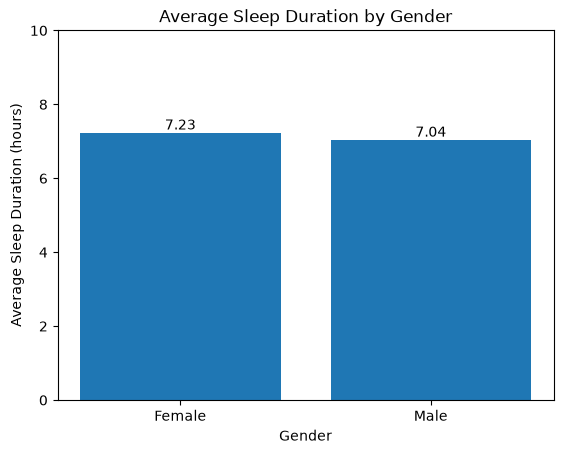

In [74]:
# Use .groupby() to compute summary statistics of Sleep Duration and Gender
print(sleep_data.groupby("Gender").agg(
    {
        "Person ID": "nunique",
        "Sleep Duration": ["mean", "median"],
    }
))

# Create barchart comparing Sleep Duration between Male and Female
bar1 = plt.bar(
    sleep_data.groupby('Gender')["Sleep Duration"].mean().index,
    sleep_data.groupby('Gender')["Sleep Duration"].mean()
)

plt.xlabel("Gender")
plt.ylabel("Average Sleep Duration (hours)")
plt.title("Average Sleep Duration by Gender")
plt.bar_label(bar1, fmt="%.2f")
plt.ylim(0, 10)
plt.show()

##### **Basic Filtering and Grouping - Sleep Duration in Female**
- Another subset of data was created for female only to understand the correlation between the seletect female's demographic variables and sleep duration better. This included:

1. Age
- We first explored the sleep duration trend with different age group, which demonstrated a clear trend that female in our dataset, who were between 51 - 60 years old tend to sleep longer.

2. Daily Step Level
- We also hypothesized that the more steps female take per day, the longer her sleep duration.
- A new variable `Daily Step Level` was created, which grouped the daily step based on the quartile range from `.describe()`, where `'Low'` <= 5,600, 5,600 < `'Medium'` < 8,000 and `'High'` >= 8000.
- The barchart diagram also came back with another surprising results, where female with lower daily steps tended to have longer duration of sleep at 7.84 hours.

(185, 13)
Age Group
36-40    39
41-45    30
46-50    30
51-55    43
56-60    33
<=35     10
Name: count, dtype: int64


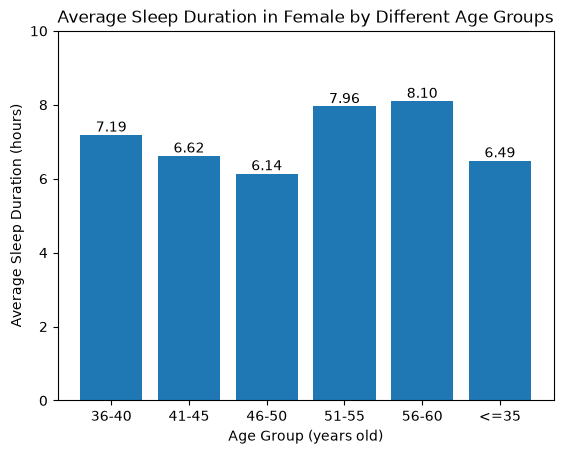

In [75]:
# Create a new subset of data only for female
sleep_data_female = sleep_data[sleep_data["Gender"] == "Female"].copy()
print(sleep_data_female.shape)

# Create a categorical variable to categorise different age groups
sleep_data_female["Age Group"] = np.select(
    [
        sleep_data_female["Age"] <= 35,
        sleep_data_female["Age"].between(36, 40),
        sleep_data_female["Age"].between(41, 45),
        sleep_data_female["Age"].between(46, 50),
        sleep_data_female["Age"].between(51, 55),
        sleep_data_female["Age"].between(56, 60)
    ],
    [
        "<=35",
        "36-40",
        "41-45",
        "46-50",
        "51-55",
        "56-60"
    ],
    default="Unknown"
)

print(sleep_data_female["Age Group"].value_counts().sort_index())

# Create barchart comparing Sleep Duration in Female at Different Age Groups
bar2 = plt.bar(
    sleep_data_female.groupby('Age Group')["Sleep Duration"].mean().index,
    sleep_data_female.groupby('Age Group')["Sleep Duration"].mean()
)

plt.xlabel("Age Group (years old)")
plt.ylabel("Average Sleep Duration (hours)")
plt.title("Average Sleep Duration in Female by Different Age Groups")
plt.bar_label(bar2, fmt="%.2f")
plt.ylim(0, 10)
plt.show()


Daily Step Level
Medium    102
Low        48
High       35
Name: count, dtype: int64


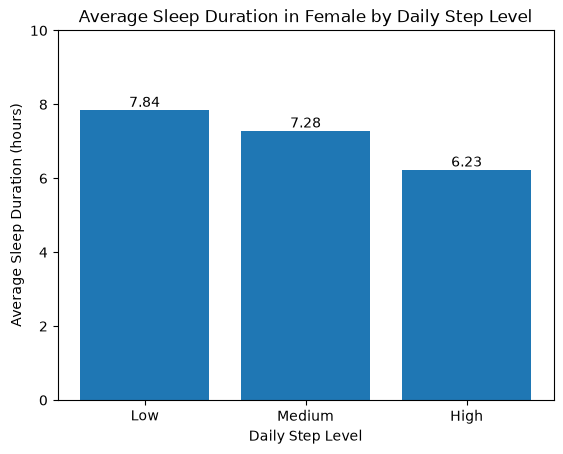

In [76]:
# Create a new categorical column to show the level of daily step between Low, Medium and High
sleep_data_female["Daily Step Level"] = sleep_data_female["Daily Steps"].apply(
    lambda x: "Low" if x <= 5600 else "Medium" if x < 8000 else "High"
)
print(sleep_data_female["Daily Step Level"].value_counts(dropna=False))

# Create barchart comparing Sleep Duration between different daily steps level taken in Female
step_order = ["Low", "Medium", "High"]

bar3 = plt.bar(
    sleep_data_female.groupby("Daily Step Level")["Sleep Duration"]
    .mean()
    .reindex(step_order)
    .index,

    sleep_data_female.groupby("Daily Step Level")["Sleep Duration"]
    .mean()
    .reindex(step_order)
)

plt.xlabel("Daily Step Level")
plt.ylabel("Average Sleep Duration (hours)")
plt.title("Average Sleep Duration in Female by Daily Step Level")
plt.bar_label(bar3, fmt="%.2f")
plt.ylim(0, 10)
plt.show()
pandas_analysis_end = time.perf_counter() # Stop the timer for data manipulation

##### **Machine Learning Algorithm - Scenario 1**
- In the new female dataset, we would like to see if simply just `'Daily Steps'` can predict `'Sleep Duration'`.
- Using the model from `scikit-learn`, we started by defining the variables in our model, where our explanatory variable is `'Daily Steps'`, which is the approximate number of steps each female took on a daily basis and dependent variable is `'Sleep Duration'`, which is the number of hours female slept per day.

- In this scenarion, 3 models selected included:
1. Linear Regression Model - This provides a good testing for simple linear relationship as our baseline.
2. Decision Tree Model - This provides a good testing for numerical variables even when they are discrete rather than continuous, because they can split the values into ranges/groups and capture non-linear relationships.
3. Random Forest Model - This combines multiple decision trees, allowing it to capture more complex relationships than a single decision tree model.
- The results indicated that the Decision Tree model performed best, with the highest R² (0.740) and the lowest RMSE (0.451). This suggests that the relationship between 'Daily Steps' and 'Sleep Duration' may be non-linear. This finding is also consistent with the visualization, which indicates that a linear regression model may not be the most suitable approach for predicting 'Sleep Duration', as the relationship between the variables does not appear to follow a clear linear pattern and can be further improved in the next scenario.

In [77]:
# Machine Learning Algorithm
pandas_ml_start = time.perf_counter() # Start the timer for machine learning execution

# Scenario 1 - Sleep Duration vs Daily Steps
# We want to see if daily steps can predict hours of sleep in female
x1 = sleep_data_female[["Daily Steps"]]
y1 = sleep_data_female["Sleep Duration"]

# Perform random split between the train and test data set. Here we are testing 20% of the data.
x1_train, x1_test, y1_train, y1_test = train_test_split(
    x1, y1, test_size=0.2, random_state=100
)

# Model 1: Linear Regression
model1 = LinearRegression()
model1.fit(x1_train, y1_train)
y1_m1_pred = model1.predict(x1_test)
print("R² from Linear Regression:", r2_score(y1_test, y1_m1_pred))
print("RMSE from Linear Regression:", np.sqrt(mean_squared_error(y1_test, y1_m1_pred)))

# Model 2: Decision Tree Regression
model2 = DecisionTreeRegressor(random_state=100)
model2.fit(x1_train, y1_train)
y1_m2_pred = model2.predict(x1_test)
print("R² from Decision Tree Regression:", r2_score(y1_test, y1_m2_pred))
print("RMSE from Decision Tree Regression:", np.sqrt(mean_squared_error(y1_test, y1_m2_pred)))

# Model 3: Random Forest Regression
model3 = RandomForestRegressor(random_state=100)
model3.fit(x1_train, y1_train)
y1_m3_pred = model3.predict(x1_test)
print("R² from Random Forest Regression:", r2_score(y1_test, y1_m3_pred))
print("RMSE from Random Forest Regression:", np.sqrt(mean_squared_error(y1_test, y1_m3_pred)))

R² from Linear Regression: 0.103820457122213
RMSE from Linear Regression: 0.8379980852972218
R² from Decision Tree Regression: 0.7404933670143714
RMSE from Decision Tree Regression: 0.45094102198593283
R² from Random Forest Regression: 0.7130931071562159
RMSE from Random Forest Regression: 0.47415027239289487


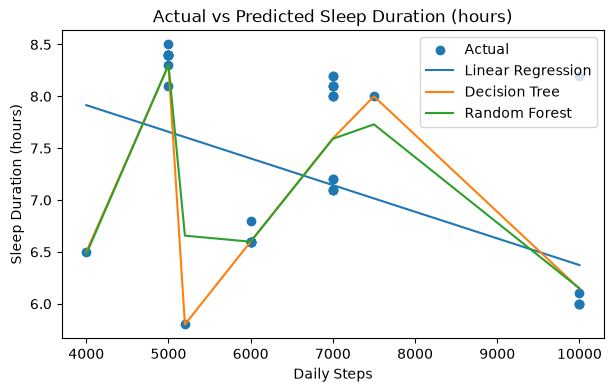

In [78]:
# Visualization the prediction in Scenario 1
plot_data = pd.DataFrame({
    "Daily Steps": x1_test["Daily Steps"].values,
    "Actual": y1_test.values,
    "Linear Regression": y1_m1_pred,
    "Decision Tree": y1_m2_pred,
    "Random Forest": y1_m3_pred
}).sort_values("Daily Steps")

plt.figure(figsize=(7, 4))
plt.scatter(plot_data["Daily Steps"], plot_data["Actual"], label="Actual")
plt.plot(plot_data["Daily Steps"], plot_data["Linear Regression"], label="Linear Regression")
plt.plot(plot_data["Daily Steps"], plot_data["Decision Tree"], label="Decision Tree")
plt.plot(plot_data["Daily Steps"], plot_data["Random Forest"], label="Random Forest")

plt.xlabel("Daily Steps")
plt.ylabel("Sleep Duration (hours)")
plt.title("Actual vs Predicted Sleep Duration (hours)")
plt.legend()
plt.show()

##### **Machine Learning Algorithm - Scenario 2**
- In this scenario, we assumed that the relationship between 'Daily Steps' and 'Sleep Duration' was no longer linear. In addition, we hypothesized that 'Age' could also have a strong influence on sleep duration.
- We continued with the tree-based models from the previous scenario and added a Gradient Boosting model, which is well suited to capturing non-linear relationships. Gradient Boosting combines multiple small decision trees, with each subsequent tree focusing on correcting the errors made by the previous trees.
- The results showed that all three models performed well, with Random Forest performing best (R² = 0.919, RMSE = 0.225). This indicated slightly higher predictive accuracy compared with Gradient Boosting and Decision Tree.
- Adding 'Age' substantially improved model performance. For Decision Tree model, R² increased from 0.74 to 0.91, while RMSE decreased from 0.45 to 0.23, while for Random Forest model, R² increased from 0.71 to 0.92, while RMSE decreased from 0.47 to 0.23. 

In [79]:
# Machine Learning Algorithm
# Scenario 2 - Sleep Duration vs Daily Steps & Age
x2 = sleep_data[["Daily Steps", "Age"]]
y2 = sleep_data["Sleep Duration"]

# Perform random split between the train and test data set. Here we are testing 20% of the data.
x2_train, x2_test, y2_train, y2_test = train_test_split(
    x2, y2, test_size=0.2, random_state=100
)

# Model 4: Decision Tree Regression
model4 = DecisionTreeRegressor(random_state=100)
model4.fit(x2_train, y2_train)
y2_m4_pred = model4.predict(x2_test)
print("R² from Decision Tree Regression:", r2_score(y2_test, y2_m4_pred))
print("RMSE from Decision Tree Regression:", np.sqrt(mean_squared_error(y2_test, y2_m4_pred)))

# Model 5: Random Forest Regression
model5 = RandomForestRegressor(random_state=100)
model5.fit(x2_train, y2_train)
y2_m5_pred = model5.predict(x2_test)
print("R² from Random Forest Regression:", r2_score(y2_test, y2_m5_pred))
print("RMSE from Random Forest Regression:", np.sqrt(mean_squared_error(y2_test, y2_m5_pred)))

# Model 6: Gradient Boosting Regression
model6 = GradientBoostingRegressor(random_state=100)
model6.fit(x2_train, y2_train)
y2_m6_pred = model6.predict(x2_test)
print("R² from Gradient Boosting Regression:", r2_score(y2_test, y2_m6_pred))
print("RMSE from Gradient Boosting Regression:", np.sqrt(mean_squared_error(y2_test, y2_m6_pred)))

R² from Decision Tree Regression: 0.9131656927993976
RMSE from Decision Tree Regression: 0.23363641659118506
R² from Random Forest Regression: 0.9192108400889726
RMSE from Random Forest Regression: 0.22535718589549467
R² from Gradient Boosting Regression: 0.9153885299046854
RMSE from Gradient Boosting Regression: 0.23062664710914424


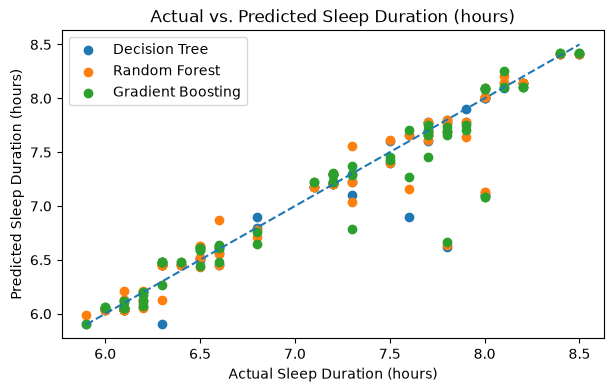

In [80]:
# Visualization the prediction in Scenario 2
# Using Predicted vs Actual
plt.figure(figsize=(7, 4))

plt.scatter(y2_test, y2_m4_pred, label="Decision Tree")
plt.scatter(y2_test, y2_m5_pred, label="Random Forest")
plt.scatter(y2_test, y2_m6_pred, label="Gradient Boosting")

# Perfect prediction line
plt.plot(
    [y2_test.min(), y2_test.max()],
    [y2_test.min(), y2_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Sleep Duration (hours)")
plt.ylabel("Predicted Sleep Duration (hours)")
plt.title("Actual vs. Predicted Sleep Duration (hours)")
plt.legend()
plt.show()
pandas_ml_end = time.perf_counter() # Stop the timer for machine learning execution

### **Data Analysis with Polars**
The main purpose of this section is:
1. Replicating the command that has been run via Pandas for Polars exposure. Here the code is intentionally planned to be as similar as possible for runtime measurements.
2. Measuring the overall runtime for loading the file up until the last command for comparison with Pandas

In [81]:
# Time Counter for Polars Performance
polars_read_start = time.perf_counter()

In [82]:
# Import Dataset
sleep_data_pl = pl.read_csv('Sleep_health_and_lifestyle_dataset.csv')
polars_read_end = time.perf_counter() # Stop the timer for reading CSV file
polars_analysis_start = time.perf_counter() # Start the timer for data manipulation

##### **Basic Data Inspection**

In [83]:
# Check on the first 3 rows and last 3 rows to have the first glimpse of the dataset
print(sleep_data_pl.head(3))
print(sleep_data_pl.tail(3))

shape: (3, 13)
┌───────────┬────────┬─────┬────────────┬───┬────────────────┬────────────┬───────┬──────────┐
│ Person ID ┆ Gender ┆ Age ┆ Occupation ┆ … ┆ Blood Pressure ┆ Heart Rate ┆ Daily ┆ Sleep    │
│ ---       ┆ ---    ┆ --- ┆ ---        ┆   ┆ ---            ┆ ---        ┆ Steps ┆ Disorder │
│ i64       ┆ str    ┆ i64 ┆ str        ┆   ┆ str            ┆ i64        ┆ ---   ┆ ---      │
│           ┆        ┆     ┆            ┆   ┆                ┆            ┆ i64   ┆ str      │
╞═══════════╪════════╪═════╪════════════╪═══╪════════════════╪════════════╪═══════╪══════════╡
│ 1         ┆ Male   ┆ 27  ┆ Software   ┆ … ┆ 126/83         ┆ 77         ┆ 4200  ┆ None     │
│           ┆        ┆     ┆ Engineer   ┆   ┆                ┆            ┆       ┆          │
│ 2         ┆ Male   ┆ 28  ┆ Doctor     ┆ … ┆ 125/80         ┆ 75         ┆ 10000 ┆ None     │
│ 3         ┆ Male   ┆ 28  ┆ Doctor     ┆ … ┆ 125/80         ┆ 75         ┆ 10000 ┆ None     │
└───────────┴────────┴─────┴───────

In [84]:
# Check the number of dataset rows and columns
print(sleep_data_pl.shape)

# View the column names
print(sleep_data_pl.columns)

# View dataset's schema - Polars do not have .info()
print(sleep_data_pl.schema)

# View summary statistics of the dataset such as count, mean, standard deviation, min, and max
print(sleep_data_pl.describe())

(374, 13)
['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']
Schema({'Person ID': Int64, 'Gender': String, 'Age': Int64, 'Occupation': String, 'Sleep Duration': Float64, 'Quality of Sleep': Int64, 'Physical Activity Level': Int64, 'Stress Level': Int64, 'BMI Category': String, 'Blood Pressure': String, 'Heart Rate': Int64, 'Daily Steps': Int64, 'Sleep Disorder': String})
shape: (9, 14)
┌────────────┬────────────┬────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ statistic  ┆ Person ID  ┆ Gender ┆ Age       ┆ … ┆ Blood     ┆ Heart     ┆ Daily     ┆ Sleep     │
│ ---        ┆ ---        ┆ ---    ┆ ---       ┆   ┆ Pressure  ┆ Rate      ┆ Steps     ┆ Disorder  │
│ str        ┆ f64        ┆ str    ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│            ┆            ┆        ┆           ┆   

##### **Check for duplicates**

In [85]:
# Check for duplicated value under 'Person ID'
print(f'Number of duplicates: {sleep_data_pl["Person ID"].is_duplicated().sum()}')

Number of duplicates: 0


##### **Check for missing values**
- Pandas interprets None as NaN, so we have to define the missing values under `'Sleep Disorder'` as None instead.

In [86]:
# View count of each category under "Sleep Disorder"
print(sleep_data_pl["Sleep Disorder"].value_counts(sort=True))

# Filter to rows with missing data under "Sleep Disorder"
sleep_data_pl.filter(pl.col("Sleep Disorder") == "None")

shape: (3, 2)
┌────────────────┬───────┐
│ Sleep Disorder ┆ count │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ None           ┆ 219   │
│ Sleep Apnea    ┆ 78    │
│ Insomnia       ┆ 77    │
└────────────────┴───────┘


Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
i64,str,i64,str,f64,i64,i64,i64,str,str,i64,i64,str
1,"""Male""",27,"""Software Engineer""",6.1,6,42,6,"""Overweight""","""126/83""",77,4200,"""None"""
2,"""Male""",28,"""Doctor""",6.2,6,60,8,"""Normal""","""125/80""",75,10000,"""None"""
3,"""Male""",28,"""Doctor""",6.2,6,60,8,"""Normal""","""125/80""",75,10000,"""None"""
8,"""Male""",29,"""Doctor""",7.8,7,75,6,"""Normal""","""120/80""",70,8000,"""None"""
9,"""Male""",29,"""Doctor""",7.8,7,75,6,"""Normal""","""120/80""",70,8000,"""None"""
…,…,…,…,…,…,…,…,…,…,…,…,…
342,"""Female""",56,"""Doctor""",8.2,9,90,3,"""Normal Weight""","""118/75""",65,10000,"""None"""
343,"""Female""",56,"""Doctor""",8.2,9,90,3,"""Normal Weight""","""118/75""",65,10000,"""None"""
344,"""Female""",57,"""Nurse""",8.1,9,75,3,"""Overweight""","""140/95""",68,7000,"""None"""


##### **Basic Filtering and Grouping - Gender vs Sleep Duration**
- Same results were observed between Pandas and Polars command.

shape: (2, 4)
┌────────┬───────────┬─────────────────────┬───────────────────────┐
│ Gender ┆ Person ID ┆ Sleep Duration Mean ┆ Sleep Duration Median │
│ ---    ┆ ---       ┆ ---                 ┆ ---                   │
│ str    ┆ u32       ┆ f64                 ┆ f64                   │
╞════════╪═══════════╪═════════════════════╪═══════════════════════╡
│ Female ┆ 185       ┆ 7.22973             ┆ 7.2                   │
│ Male   ┆ 189       ┆ 7.036508            ┆ 7.2                   │
└────────┴───────────┴─────────────────────┴───────────────────────┘


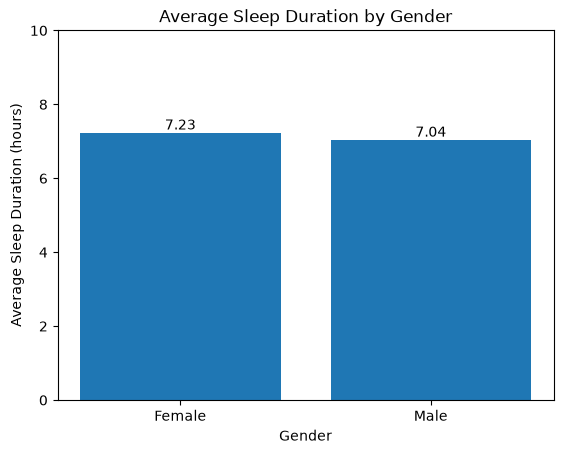

In [87]:
# Use .groupby() to compute summary statistics of Sleep Duration and Gender
sleep_duration_by_gender = sleep_data_pl.group_by("Gender").agg(
    [
        pl.col("Person ID").n_unique().alias("Person ID"),
        pl.col("Sleep Duration").mean().alias("Sleep Duration Mean"),
        pl.col("Sleep Duration").median().alias("Sleep Duration Median"),
    ]
)

print(sleep_duration_by_gender)

# Create barchart comparing Sleep Duration between Male and Female
bar_pl1 = plt.bar(
    sleep_duration_by_gender["Gender"].to_list(),
    sleep_duration_by_gender["Sleep Duration Mean"].to_list()
)
plt.xlabel("Gender")
plt.ylabel("Average Sleep Duration (hours)")
plt.title("Average Sleep Duration by Gender")
plt.bar_label(bar_pl1, fmt="%.2f")
plt.ylim(0, 10)
plt.show()

##### **Basic Filtering and Grouping - Sleep Duration in Female**

(185, 13)
shape: (6, 2)
┌───────────┬───────┐
│ Age Group ┆ count │
│ ---       ┆ ---   │
│ str       ┆ u32   │
╞═══════════╪═══════╡
│ 36-40     ┆ 39    │
│ 41-45     ┆ 30    │
│ 46-50     ┆ 30    │
│ 51-55     ┆ 43    │
│ 56-60     ┆ 33    │
│ <=35      ┆ 10    │
└───────────┴───────┘


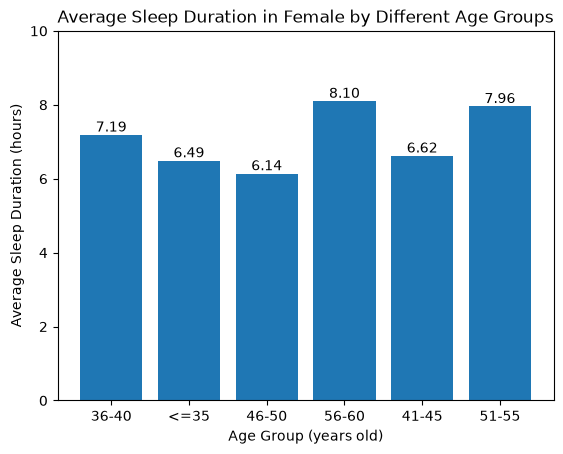

In [88]:
# Create a new subset of data only for female
sleep_data_female_pl = sleep_data_pl.filter(pl.col("Gender") == "Female")
print(sleep_data_female_pl.shape)

# Create a categorical variable to categorise different age groups
sleep_data_female_pl = sleep_data_female_pl.with_columns(
    pl.when(pl.col("Age") <= 35)
    .then(pl.lit("<=35"))
    .when(pl.col("Age").is_between(36, 40))
    .then(pl.lit("36-40"))
    .when(pl.col("Age").is_between(41, 45))
    .then(pl.lit("41-45"))
    .when(pl.col("Age").is_between(46, 50))
    .then(pl.lit("46-50"))
    .when(pl.col("Age").is_between(51, 55))
    .then(pl.lit("51-55"))
    .when(pl.col("Age").is_between(56, 60))
    .then(pl.lit("56-60"))
    .otherwise(pl.lit("Unknown"))
    .alias("Age Group")
)

print(sleep_data_female_pl["Age Group"].value_counts().sort("Age Group"))

# Create barchart comparing Sleep Duration in Female at Different Age Groups
sleep_duration_by_age = sleep_data_female_pl.group_by("Age Group").agg(
    pl.col("Sleep Duration").mean().alias("Sleep Duration")
)

bar_pl2 = plt.bar(
    sleep_duration_by_age["Age Group"].to_list(),
    sleep_duration_by_age["Sleep Duration"].to_list()
)

plt.xlabel("Age Group (years old)")
plt.ylabel("Average Sleep Duration (hours)")
plt.title("Average Sleep Duration in Female by Different Age Groups")
plt.bar_label(bar_pl2, fmt="%.2f")
plt.ylim(0, 10)
plt.show()

shape: (3, 2)
┌──────────────────┬───────┐
│ Daily Step Level ┆ count │
│ ---              ┆ ---   │
│ str              ┆ u32   │
╞══════════════════╪═══════╡
│ Medium           ┆ 102   │
│ Low              ┆ 48    │
│ High             ┆ 35    │
└──────────────────┴───────┘


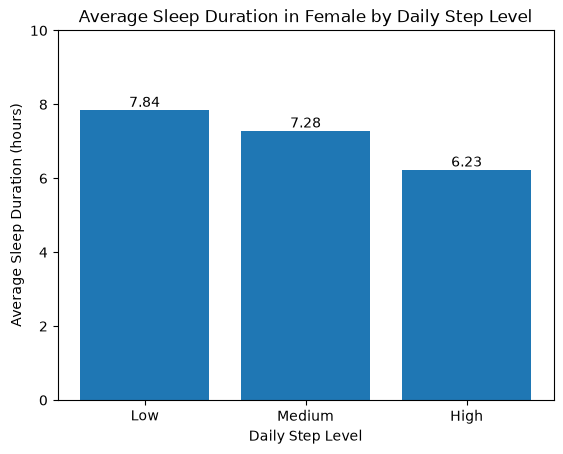

In [89]:
# Create a new categorical column to show the level of daily step between Low, Medium and High
sleep_data_female_pl = sleep_data_female_pl.with_columns(
    pl.when(pl.col("Daily Steps") <= 5600)
    .then(pl.lit("Low"))
    .when(pl.col("Daily Steps") < 8000)
    .then(pl.lit("Medium"))
    .otherwise(pl.lit("High"))
    .alias("Daily Step Level")
)

print(sleep_data_female_pl["Daily Step Level"].value_counts(sort=True))

# Create barchart comparing Sleep Duration between different daily steps level taken in Female
step_order = ["Low", "Medium", "High"]

sleep_duration_by_step = (
    sleep_data_female_pl
    .group_by("Daily Step Level")
    .agg(pl.col("Sleep Duration").mean().alias("Sleep Duration"))
)

sleep_duration_by_step = (
    sleep_duration_by_step
    .with_columns(
        pl.col("Daily Step Level").cast(pl.Enum(step_order))
    )
    .sort("Daily Step Level")
)

bar_pl3 = plt.bar(
    sleep_duration_by_step["Daily Step Level"].to_list(),
    sleep_duration_by_step["Sleep Duration"].to_list()
)

plt.xlabel("Daily Step Level")
plt.ylabel("Average Sleep Duration (hours)")
plt.title("Average Sleep Duration in Female by Daily Step Level")
plt.bar_label(bar_pl3, fmt="%.2f")
plt.ylim(0, 10)
plt.show()

polars_analysis_end = time.perf_counter() # Stop the timer for data manipulation

##### **Machine Learning Algorithm - Scenario 1**

R² from Linear Regression: 0.103820457122213
RMSE from Linear Regression: 0.8379980852972218
R² from Decision Tree Regression: 0.7404933670143714
RMSE from Decision Tree Regression: 0.45094102198593283
R² from Random Forest Regression: 0.7130931071562159
RMSE from Random Forest Regression: 0.47415027239289487


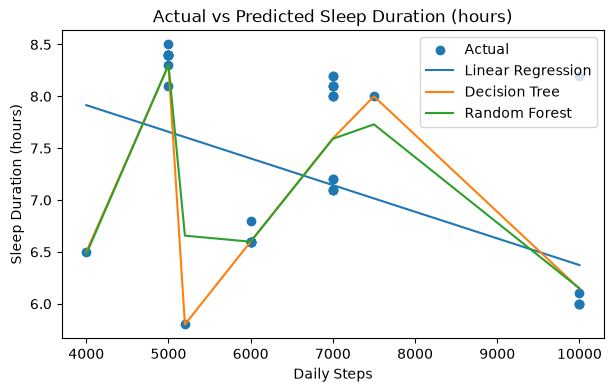

In [90]:
# Machine Learning Algorithm
polars_ml_start = time.perf_counter() # Start the timer for machine learning execution

# Scenario 1 - Sleep Duration vs Daily Steps
# We want to see if daily steps can predict hours of sleep in female
x1 = sleep_data_female_pl.select(["Daily Steps"])
y1 = sleep_data_female_pl["Sleep Duration"]

# Perform random split between the train and test data set. Here we are testing 20% of the data.
x1_train, x1_test, y1_train, y1_test = train_test_split(
    x1, y1, test_size=0.2, random_state=100
)

# Model 1: Linear Regression
model1 = LinearRegression()
model1.fit(x1_train, y1_train)
y1_m1_pred = model1.predict(x1_test)
print("R² from Linear Regression:", r2_score(y1_test, y1_m1_pred))
print("RMSE from Linear Regression:", np.sqrt(mean_squared_error(y1_test, y1_m1_pred)))

# Model 2: Decision Tree Regression
model2 = DecisionTreeRegressor(random_state=100)
model2.fit(x1_train, y1_train)
y1_m2_pred = model2.predict(x1_test)
print("R² from Decision Tree Regression:", r2_score(y1_test, y1_m2_pred))
print("RMSE from Decision Tree Regression:", np.sqrt(mean_squared_error(y1_test, y1_m2_pred)))

# Model 3: Random Forest Regression
model3 = RandomForestRegressor(random_state=100)
model3.fit(x1_train, y1_train)
y1_m3_pred = model3.predict(x1_test)
print("R² from Random Forest Regression:", r2_score(y1_test, y1_m3_pred))
print("RMSE from Random Forest Regression:", np.sqrt(mean_squared_error(y1_test, y1_m3_pred)))

# Visualization the prediction in Scenario 1
plot_data = pl.DataFrame({
    "Daily Steps": x1_test["Daily Steps"].to_list(),
    "Actual": y1_test.to_list(),
    "Linear Regression": y1_m1_pred,
    "Decision Tree": y1_m2_pred,
    "Random Forest": y1_m3_pred
}).sort("Daily Steps")

plt.figure(figsize=(7, 4))
plt.scatter(plot_data["Daily Steps"], plot_data["Actual"], label="Actual")
plt.plot(plot_data["Daily Steps"], plot_data["Linear Regression"], label="Linear Regression")
plt.plot(plot_data["Daily Steps"], plot_data["Decision Tree"], label="Decision Tree")
plt.plot(plot_data["Daily Steps"], plot_data["Random Forest"], label="Random Forest")

plt.xlabel("Daily Steps")
plt.ylabel("Sleep Duration (hours)")
plt.title("Actual vs Predicted Sleep Duration (hours)")
plt.legend()
plt.show()

##### **Machine Learning Algorithm - Scenario 2**

R² from Decision Tree Regression: 0.9131656927993976
RMSE from Decision Tree Regression: 0.23363641659118506
R² from Random Forest Regression: 0.9192108400889726
RMSE from Random Forest Regression: 0.22535718589549467
R² from Gradient Boosting Regression: 0.9153885299046854
RMSE from Gradient Boosting Regression: 0.23062664710914424


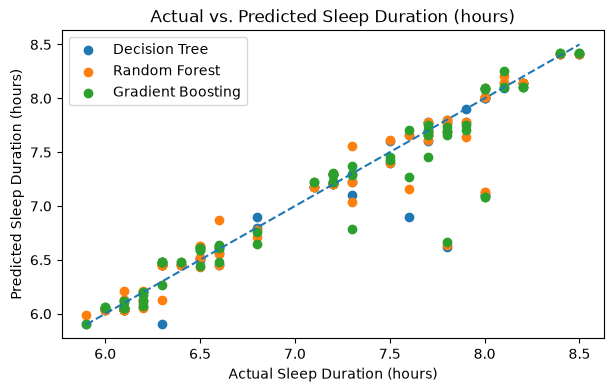

In [ ]:
# Machine Learning Algorithm
# Scenario 2 - Sleep Duration vs Daily Steps & Age
x2 = sleep_data_pl.select(["Daily Steps", "Age"])
y2 = sleep_data_pl["Sleep Duration"]

# Perform random split between the train and test data set. Here we are testing 20% of the data.
x2_train, x2_test, y2_train, y2_test = train_test_split(
    x2, y2, test_size=0.2, random_state=100
)

# Model 4: Decision Tree Regression
model4 = DecisionTreeRegressor(random_state=100)
model4.fit(x2_train, y2_train)
y2_m4_pred = model4.predict(x2_test)
print("R² from Decision Tree Regression:", r2_score(y2_test, y2_m4_pred))
print("RMSE from Decision Tree Regression:", np.sqrt(mean_squared_error(y2_test, y2_m4_pred)))

# Model 5: Random Forest Regression
model5 = RandomForestRegressor(random_state=100)
model5.fit(x2_train, y2_train)
y2_m5_pred = model5.predict(x2_test)
print("R² from Random Forest Regression:", r2_score(y2_test, y2_m5_pred))
print("RMSE from Random Forest Regression:", np.sqrt(mean_squared_error(y2_test, y2_m5_pred)))

# Model 6: Gradient Boosting Regression
model6 = GradientBoostingRegressor(random_state=100)
model6.fit(x2_train, y2_train)
y2_m6_pred = model6.predict(x2_test)
print("R² from Gradient Boosting Regression:", r2_score(y2_test, y2_m6_pred))
print("RMSE from Gradient Boosting Regression:", np.sqrt(mean_squared_error(y2_test, y2_m6_pred)))

# Visualization the prediction in Scenario 2
# Using Predicted vs Actual
plt.figure(figsize=(7, 4))

plt.scatter(y2_test, y2_m4_pred, label="Decision Tree")
plt.scatter(y2_test, y2_m5_pred, label="Random Forest")
plt.scatter(y2_test, y2_m6_pred, label="Gradient Boosting")

# Perfect prediction line
plt.plot(
    [y2_test.min(), y2_test.max()],
    [y2_test.min(), y2_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Sleep Duration (hours)")
plt.ylabel("Predicted Sleep Duration (hours)")
plt.title("Actual vs. Predicted Sleep Duration (hours)")
plt.legend()
plt.show()

polars_ml_end = time.perf_counter() # Stop the timer for machine learning execution

##### **Pandas vs Polars - Performance Measurement**
- Polars was slightly faster than Pandas for the data analysis section (0.68s vs. 0.7s), but slower for the machine learning section (0.95s vs. 0.76s).
- Overall, this partially aligns with the general consensus that Polars can outperform Pandas, particularly for data manipulation, but Polars’ performance depends on the type of task, and it may not be faster when using tools like scikit-learn.

Pandas Read runtime: 0.019967 seconds
Pandas Analysis runtime: 0.701528 seconds
Pandas ML runtime: 0.757290 seconds
Polars Read runtime: 0.013171 seconds
Polars Analysis runtime: 0.683044 seconds
Polars ML runtime: 0.946754 seconds


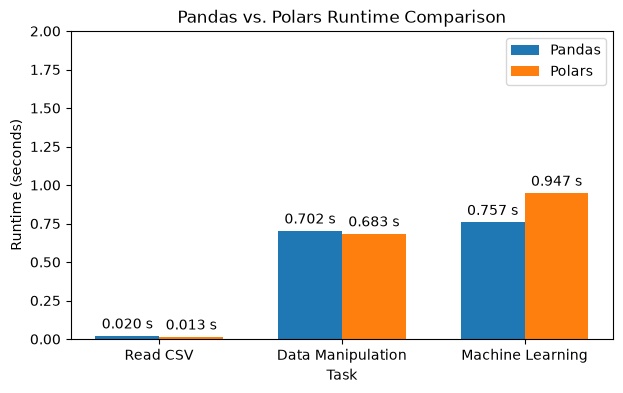

In [ ]:
print(f"Pandas Read runtime: {pandas_read_end-pandas_read_start:.6f} seconds")
print(f"Pandas Analysis runtime: {pandas_analysis_end-pandas_analysis_start:.6f} seconds")
print(f"Pandas ML runtime: {pandas_ml_end-pandas_ml_start:.6f} seconds")
print(f"Polars Read runtime: {polars_read_end-polars_read_start:.6f} seconds")
print(f"Polars Analysis runtime: {polars_analysis_end-polars_analysis_start:.6f} seconds")
print(f"Polars ML runtime: {polars_ml_end-polars_ml_start:.6f} seconds")

# Visualize performance comparison
tasks = ["Read CSV", "Data Manipulation", "Machine Learning"]
pandas_runtime = [
    pandas_read_end - pandas_read_start,
    pandas_analysis_end - pandas_analysis_start,
    pandas_ml_end - pandas_ml_start
]
polars_runtime = [
    polars_read_end - polars_read_start,
    polars_analysis_end - polars_analysis_start,
    polars_ml_end - polars_ml_start
]

x = np.arange(len(tasks))
width = 0.35

plt.figure(figsize=(7, 4))
bar_pandas = plt.bar(x - width/2, pandas_runtime, width, label="Pandas")
bar_polars = plt.bar(x + width/2, polars_runtime, width, label="Polars")

plt.bar_label(bar_pandas, fmt="%.3f s", padding=3)
plt.bar_label(bar_polars, fmt="%.3f s", padding=3)

plt.xlabel("Task")
plt.ylabel("Runtime (seconds)")
plt.title("Pandas vs. Polars Runtime Comparison")
plt.xticks(x, tasks)
plt.ylim(0, 2)
plt.legend()
plt.show()